Nama: Nurfira Ramadan
Nim : 20230410500043

In [1]:
import pandas as pd
import numpy as np
from google.colab import drive

In [3]:
from google.colab import drive
import pandas as pd # Import pandas here

drive.mount('/content/drive')
file_path = '/content/drive/My Drive/p1/bbc-text.xlsx'
df = pd.read_excel(file_path)
print(df.head(20))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
         category                                               text
0            tech  tv future in the hands of viewers with home th...
1        business  worldcom boss  left books alone  former worldc...
2           sport  tigers wary of farrell  gamble  leicester say ...
3           sport  yeading face newcastle in fa cup premiership s...
4   entertainment  ocean s twelve raids box office ocean s twelve...
5        politics  howard hits back at mongrel jibe michael howar...
6        politics  blair prepares to name poll date tony blair is...
7           sport  henman hopes ended in dubai third seed tim hen...
8           sport  wilkinson fit to face edinburgh england captai...
9   entertainment  last star wars  not for children  the sixth an...
10  entertainment  berlin cheers for anti-nazi film a german movi...
11       business  virgin blue shares plumm

Bag of Words (BoW): Metode sederhana yang menghitung jumlah kemunculan kata dalam dokumen tanpa mempertimbangkan urutan kata.

In [7]:
import re
from sklearn.feature_extraction.text import CountVectorizer

# Ambil kolom
df = df[['category', 'text']]
df.columns = ['label', 'text']

# Ambil 10 data pertama
df = df.iloc[:10]

# Preprocessing
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

df['text'] = df['text'].apply(clean_text)

# BoW
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['text'])

# Tampilkan hasil
bow_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

print("Teks:\n", df['text'])
print("\nBoW:\n", bow_df)

Teks:
 0    tv future in the hands of viewers with home th...
1    worldcom boss  left books alone  former worldc...
2    tigers wary of farrell  gamble  leicester say ...
3    yeading face newcastle in fa cup premiership s...
4    ocean s twelve raids box office ocean s twelve...
5    howard hits back at mongrel jibe michael howar...
6    blair prepares to name poll date tony blair is...
7    henman hopes ended in dubai third seed tim hen...
8    wilkinson fit to face edinburgh england captai...
9    last star wars  not for children  the sixth an...
Name: text, dtype: object

BoW:
    abiding  abilities  able  about  according  accounting  accused  across  \
0        1          0     0      4          1           0        0       0   
1        0          1     0      1          0           5        1       0   
2        0          0     0      1          0           0        0       1   
3        0          0     0      0          0           0        0       0   
4        0          

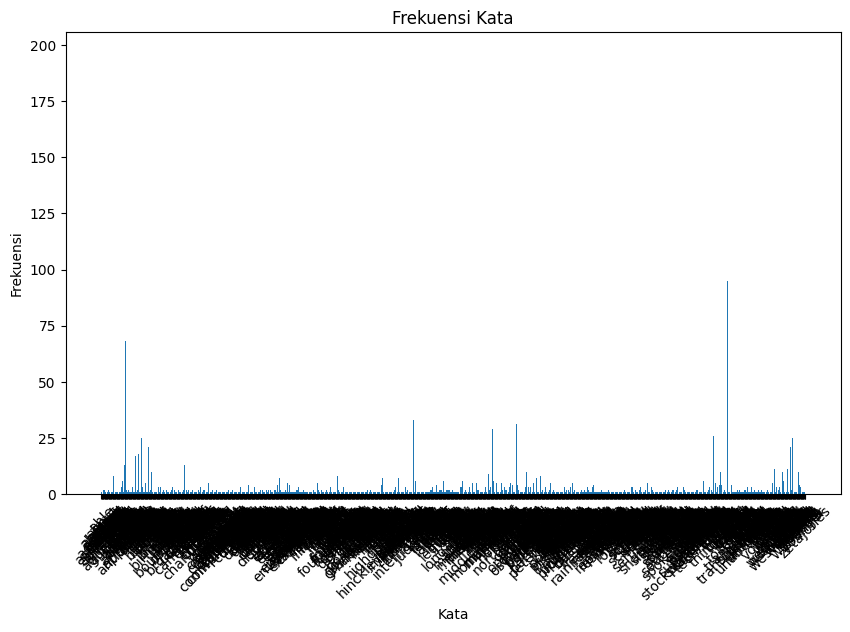

In [10]:
#Visualisasi Frekuensi Kata
#Bar Chart

plt.figure(figsize= (10, 6))
plt.bar(list (word_counts.keys()), list (word_counts.values()))
plt.xlabel('Kata')
plt.ylabel('Frekuensi')
plt.title('Frekuensi Kata')
plt.xticks(rotation=45)
plt.show()

10 kata dengan frekuensi tertinggi

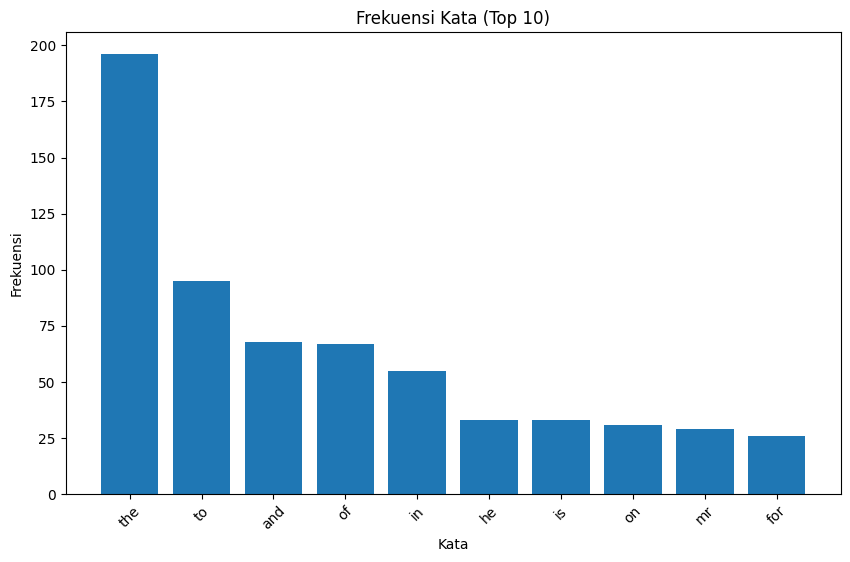

In [11]:
# Ambil 10 kata dengan frekuensi tertinggi
top_words = dict(sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:10])

# Visualisasi
plt.figure(figsize=(10, 6))
plt.bar(list(top_words.keys()), list(top_words.values()))
plt.xlabel('Kata')
plt.ylabel('Frekuensi')
plt.title('Frekuensi Kata (Top 10)')
plt.xticks(rotation=45)
plt.show()

10 kata dengan frekuensi terendah

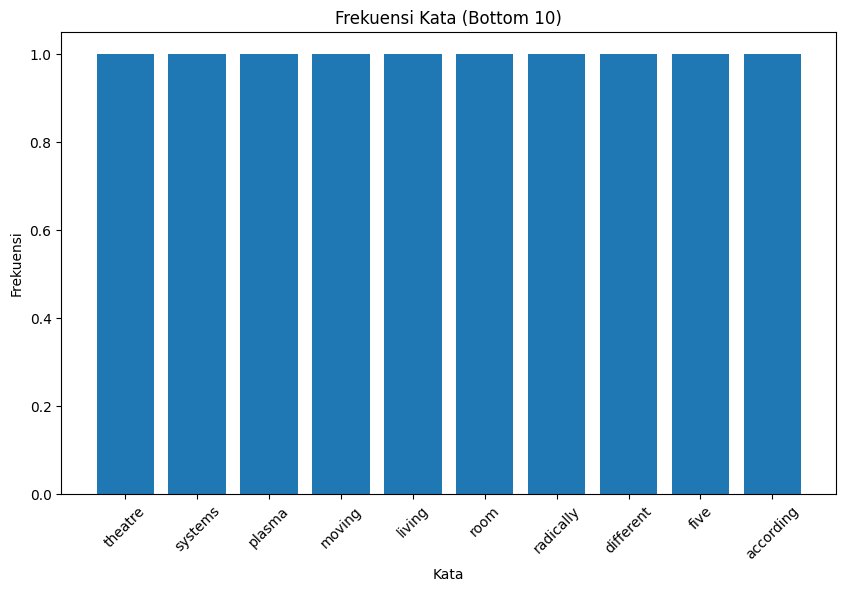

In [15]:
# Ambil 10 kata dengan frekuensi terendah
bottom_words = dict(sorted(word_counts.items(), key=lambda x: x[1])[:10])

# Visualisasi
plt.figure(figsize=(10, 6))
plt.bar(list(bottom_words.keys()), list(bottom_words.values()))
plt.xlabel('Kata')
plt.ylabel('Frekuensi')
plt.title('Frekuensi Kata (Bottom 10)')
plt.xticks(rotation=45)
plt.show()

frukuensi kata pada baris pertama data

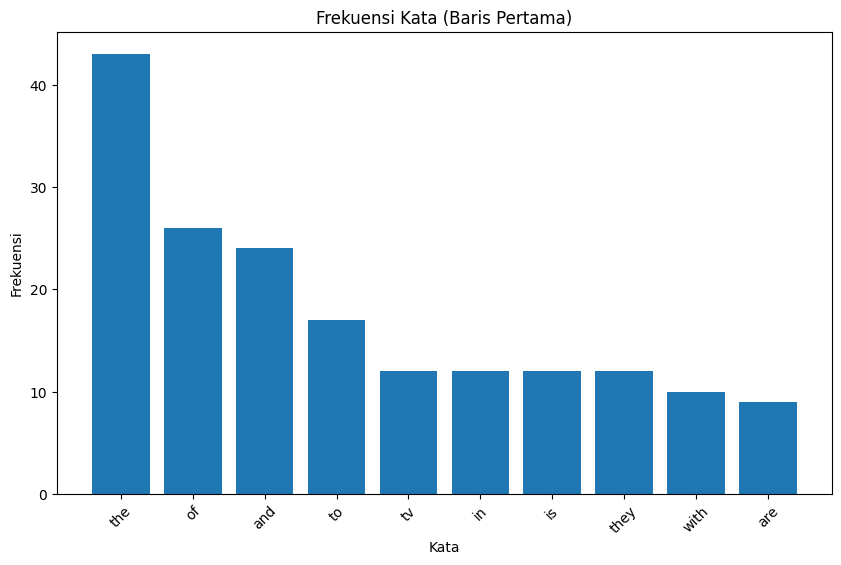

In [12]:
# Ambil 1 baris pertama dan hitung frekuensi
from collections import Counter

text = df['text'].iloc[0]
word_counts = Counter(text.split())

# (Opsional) ambil 10 kata teratas biar rapi
word_counts = dict(sorted(word_counts.items(), key=lambda x: x[1], reverse=True)[:10])

# Visualisasi
plt.figure(figsize=(10, 6))
plt.bar(list(word_counts.keys()), list(word_counts.values()))
plt.xlabel('Kata')
plt.ylabel('Frekuensi')
plt.title('Frekuensi Kata (Baris Pertama)')
plt.xticks(rotation=45)
plt.show()

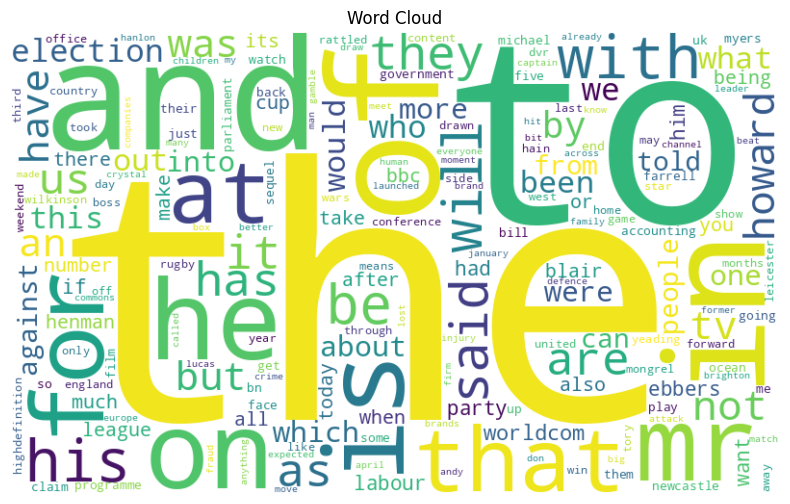

In [17]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Calculate word frequencies from bow_df
word_counts = bow_df.sum().to_dict()

#World Cloud
wordcloud = WordCloud(width=800, height=480, background_color= 'white').generate_from_frequencies (word_counts)

plt.figure(figsize= (10, 6))
plt.imshow(wordcloud, interpolation= 'bilinear')
plt.axis('off')
plt.title('Word Cloud')
plt.show()